<div align="right">
АС-23-05, Тищенко Кирилл, Вариант №97
</div>

In [9]:
import numpy as np
import matplotlib.pyplot as plt

from matplotlib import cm
from scipy.optimize import minimize
from mpl_toolkits.mplot3d import Axes3D

# Лабораторная работа №3 "Прямые методы многомерной минимизации"

$$f(\mathbf{x}) = 194x_1^2 + 376x_1x_2 + 194x_2^2 + 31x_1 - 229x_2 + 4$$

In [10]:
def f(x):
    x1, x2 = x
    return 194 * x1 ** 2 + 376 * x1 * x2 + 194 * x2 ** 2 + 31 * x1 - 229 * x2 + 4

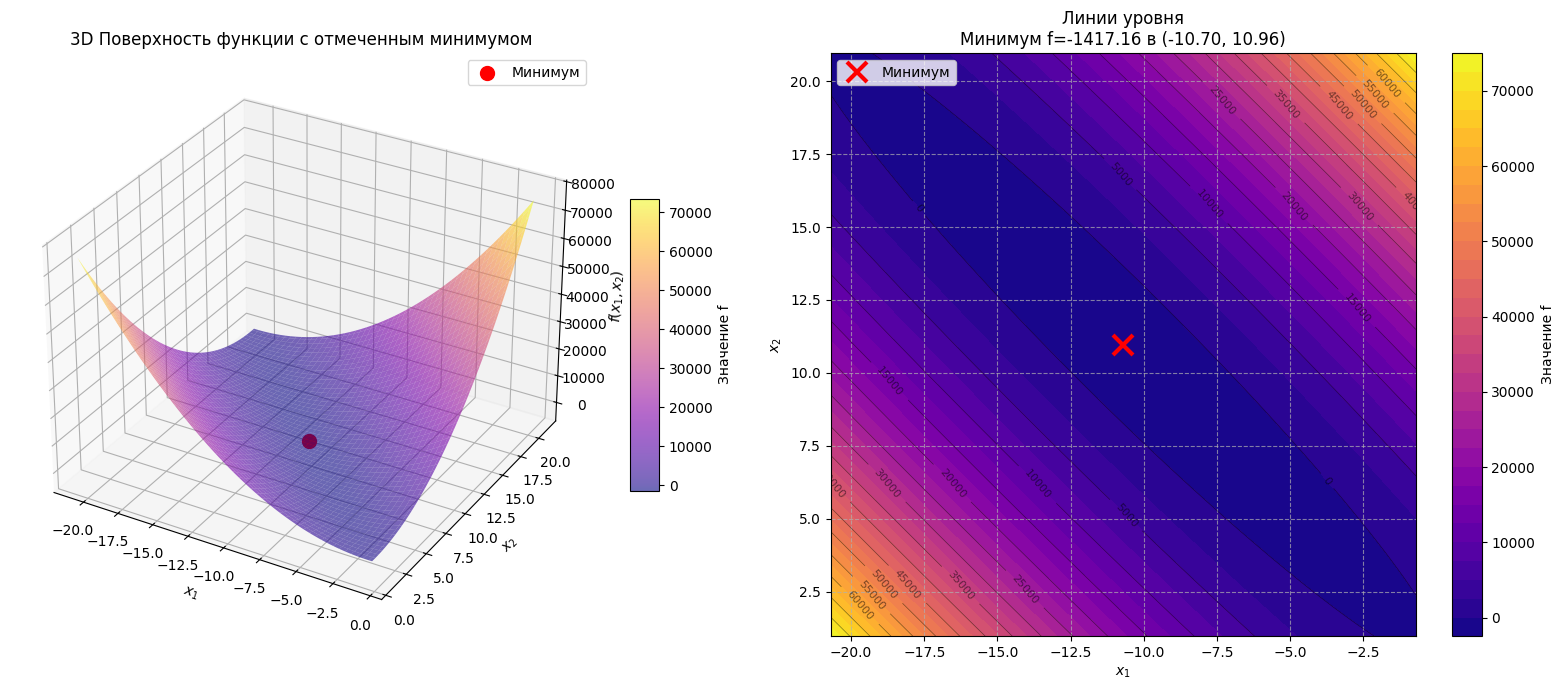

Точка минимума
x1 = -10.7038
x2 = 10.9629
Значение функции в этой точке: -1417.1619


In [11]:
x_min_arr = np.array([-10.7037581, 10.96292084])
f_min_val = -1417.1618673642563

buffer = 10
x1_range = np.linspace(x_min_arr[0] - buffer, x_min_arr[0] + buffer, 100)
x2_range = np.linspace(x_min_arr[1] - buffer, x_min_arr[1] + buffer, 100)

X1, X2 = np.meshgrid(x1_range, x2_range)

def f_mesh(x1, x2):
    return 194*x1**2 + 376*x1*x2 + 194*x2**2 + 31*x1 - 229*x2 + 4

Z = f_mesh(X1, X2)


fig = plt.figure(figsize=(16, 7))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf = ax1.plot_surface(X1, X2, Z, cmap='plasma', edgecolor='none', alpha=0.6)
ax1.scatter(x_min_arr[0], x_min_arr[1], f_min_val, color='red', s=100, label='Минимум')
ax1.set_title('3D Поверхность функции с отмеченным минимумом')
ax1.set_xlabel('$x_1$')
ax1.set_ylabel('$x_2$')
ax1.set_zlabel('$f(x_1, x_2)$')
ax1.legend()
fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=10, label='Значение f')


ax2 = fig.add_subplot(1, 2, 2)
contour_filled = ax2.contourf(X1, X2, Z, levels=30, cmap='plasma')
fig.colorbar(contour_filled, ax=ax2, label='Значение f')
contours = ax2.contour(X1, X2, Z, levels=15, colors='black', alpha=0.5, linewidths=0.5)
ax2.clabel(contours, inline=True, fontsize=8)
ax2.plot(x_min_arr[0], x_min_arr[1], 'rx', markersize=15, markeredgewidth=3, label='Минимум')

ax2.set_title(f'Линии уровня\nМинимум f={f_min_val:.2f} в ({x_min_arr[0]:.2f}, {x_min_arr[1]:.2f})')
ax2.set_xlabel('$x_1$')
ax2.set_ylabel('$x_2$')
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend()

plt.tight_layout()
plt.show()

x0 = [0, 0]
res = minimize(f, x0, method='BFGS')

print(f"Точка минимума\nx1 = {res.x[0]:.4f}\nx2 = {res.x[1]:.4f}")
print(f"Значение функции в этой точке: {res.fun:.4f}")

## 1. Метод Розенброка

In [16]:
def rosenbrock_optimization(func, x_start, h_init=[0.1, 0.1], eps=1e-5, max_rotations=100):
    x_curr = np.array(x_start, dtype=float)
    h = np.array(h_init, dtype=float)
    n = len(x_curr)  
    D = np.eye(n)
    alpha, beta = 3.0, 0.5    
    history = [x_curr.copy()]
    iteration_count = 0 
    func_evals = 1

    for k in range(max_rotations):
        iteration_count += 1
        x_start_iter = x_curr.copy()
        success = np.zeros(n, dtype=bool)
        failure = np.zeros(n, dtype=bool)
        while not (np.all(success) and np.all(failure)):
            for i in range(n):
                x_new = x_curr + h[i] * D[:, i]
                func_evals += 1
                if func(x_new) < func(x_curr):
                    x_curr = x_new
                    h[i] *= alpha
                    success[i] = True
                    history.append(x_curr.copy())
                else:
                    h[i] *= -beta
                    failure[i] = True
            if np.linalg.norm(h) < eps:
                return x_curr, iteration_count, history, func_evals
        S = x_curr - x_start_iter
        if np.linalg.norm(S) < eps:
            break    
        d1_new = S / np.linalg.norm(S)
        d2_new = np.array([-d1_new[1], d1_new[0]]) 
        D = np.column_stack((d1_new, d2_new))
        h = np.array(h_init, dtype=float)
    return x_curr, iteration_count, history, func_evals

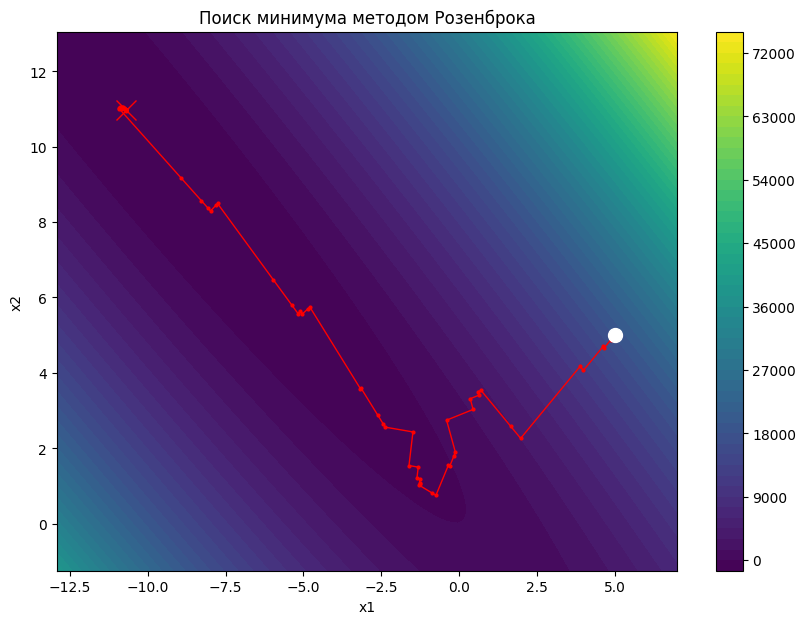

x1 = -10.70374
x2 = 10.9629
f(x) = -1417.1619
Всего итераций (поворотов осей): 21
Всего вычислений функции: 293


In [15]:
start_point = [5, 5]
min_point, iters, path, func_evals = rosenbrock_optimization(f, start_point)
path = np.array(path)
x1_vals = np.linspace(min(path[:,0])-2, max(path[:,0])+2, 100)
x2_vals = np.linspace(min(path[:,1])-2, max(path[:,1])+2, 100)
X1, X2 = np.meshgrid(x1_vals, x2_vals)
Z = 194 * X1 ** 2 + 376 * X1 * X2 + 194 * X2 ** 2 + 31 * X1 - 229 * X2 + 4

plt.figure(figsize=(10, 7))
cp = plt.contourf(X1, X2, Z, levels=50, cmap='viridis')
plt.colorbar(cp)
plt.plot(path[:, 0], path[:, 1], 'r.-', markersize=4, linewidth=1)
plt.plot(start_point[0], start_point[1], 'white', marker='o', markersize=10)
plt.plot(min_point[0], min_point[1], 'red', marker='x', markersize=15)

plt.title('Поиск минимума методом Розенброка')
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

print(f"x1 = {min_point[0]:.5f}")
print(f"x2 = {min_point[1]:.4f}")
print(f"f(x) = {f(min_point):.4f}")
print(f"Всего итераций (поворотов осей): {iters}")
print(f"Всего вычислений функции: {func_evals}")

## 2. Метод Нелдера-Мида

In [17]:
def nelder_mead_optimization(func, x_start, step=1.0, eps=1e-6, max_iter=200):
    rho, chi, psi, sigma = 1, 2, 0.5, 0.5
    x1 = np.array(x_start, dtype=float)
    x2 = x1 + np.array([step, 0])
    x3 = x1 + np.array([0, step])
    simplex = [x1, x2, x3]
    history = [np.array(simplex)] 
    iterations = 0
    func_evals = 3

    for i in range(max_iter):
        iterations += 1
        simplex.sort(key=func)
        func_evals += 3
        history.append(np.array(simplex))
        best, second_worst, worst = simplex[0], simplex[1], simplex[2]
        if np.linalg.norm(worst - best) < eps:
            break
        centroid = (best + second_worst) / 2
        xr = centroid + rho * (centroid - worst)
        func_evals += 1
        if func(best) <= func(xr) < func(second_worst):
            simplex[-1] = xr
            continue
        if func(xr) < func(best):
            xe = centroid + chi * (xr - centroid)
            func_evals += 1
            simplex[-1] = xe if func(xe) < func(xr) else xr
            func_evals += 1
            continue
        xc = centroid + psi * (worst - centroid) if func(xr) >= func(worst) else centroid + psi * (xr - centroid)
        func_evals += 1
        if func(xc) < func(worst) and func(xc) < func(xr):
            simplex[-1] = xc
            continue
        simplex[1] = best + sigma * (simplex[1] - best)
        simplex[2] = best + sigma * (simplex[2] - best)
        func_evals += 2
    return simplex[0], history, iterations, func_evals

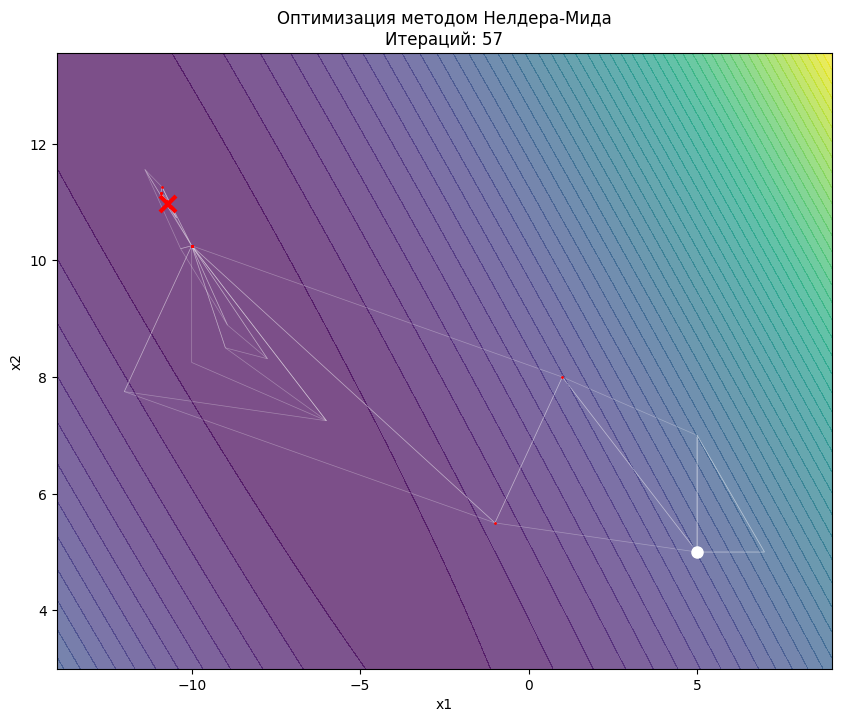

Точка минимума:
x1 = -10.7038
x2 = 10.9629
Значение функции: -1417.1619
Всего итераций: 57
Всего вызовов функции: 286


In [18]:
start_p = [5, 5]
min_p, simplex_history, total_iters, func_evals = nelder_mead_optimization(f, start_p, step=2.0)
path_points = np.vstack(simplex_history)
x1_range = np.linspace(np.min(path_points[:,0])-2, np.max(path_points[:,0])+2, 100)
x2_range = np.linspace(np.min(path_points[:,1])-2, np.max(path_points[:,1])+2, 100)
X1, X2 = np.meshgrid(x1_range, x2_range)
Z = f([X1, X2])

plt.figure(figsize=(10, 8))
plt.contourf(X1, X2, Z, levels=50, cmap='viridis', alpha=0.7)
for i, tri in enumerate(simplex_history):
    polygon = plt.Polygon(tri, fill=False, edgecolor='white', alpha=0.3, linewidth=0.5)
    plt.gca().add_patch(polygon)
    plt.plot(tri[0,0], tri[0,1], 'r.', markersize=2)
plt.plot(start_p[0], start_p[1], 'wo', markersize=8)
plt.plot(min_p[0], min_p[1], 'rx', markersize=12, markeredgewidth=3)
plt.title(f'Оптимизация методом Нелдера-Мида\nИтераций: {total_iters}')
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

print("Точка минимума:")
print(f"x1 = {min_p[0]:.4f}")
print(f"x2 = {min_p[1]:.4f}")
print(f"Значение функции: {f(min_p):.4f}")
print(f"Всего итераций: {total_iters}")
print(f"Всего вызовов функции: {func_evals}")

| Параметр | x1 | x2 | f(x1, x2) | Число итераций | Число вызовов функции |
| :--- | :---: | :---: | :---: | :---: | :---: |
| **Пакетный метод** | -10.7038 | 10.9629 | -1417.1619 | - | - |
| **Метод Розенброка** | -10.7038 | 10.9629 | -1417.1619 | 21 | 293 |
| **Метод Нелдера-Мида** | -10.7038 | 10.9629 | -1417.1619 | 57 | 286 |

## 3. Оптимизация функции Розенброка

$$f(x) = 100(x_1^2 - x_2)^2 + (x_1 - 1)^2$$

In [19]:
def f_rozenbrok(x):
    x1, x2 = x[0], x[1]
    return 100 * (x1**2 - x2)**2 + (x1 - 1)**2

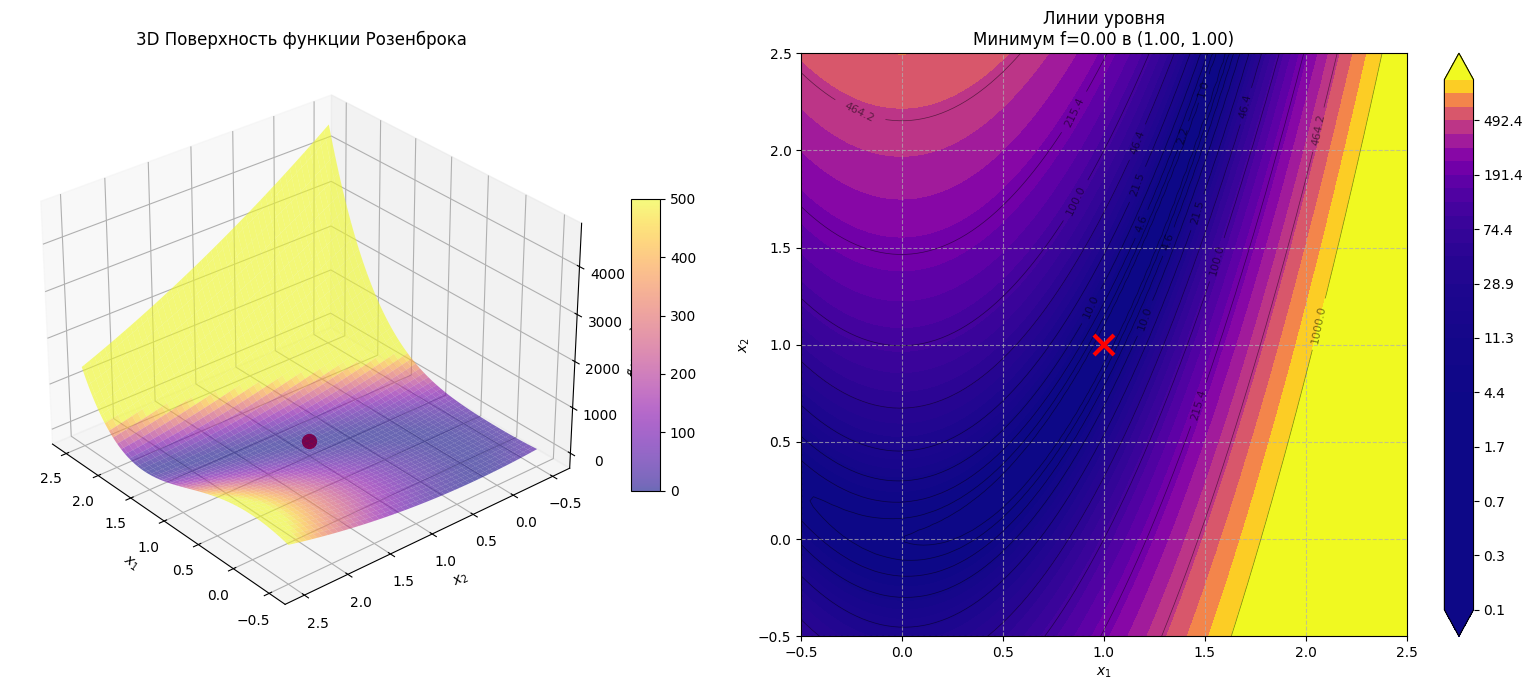

Точка минимума
x1 = 1.0000
x2 = 1.0000
Значение функции в этой точке: 0.0000


In [20]:
x_min_arr = np.array([1.0, 1.0])
f_min_val = f_rozenbrok(x_min_arr)

buffer = 1.5
x1_range = np.linspace(x_min_arr[0] - buffer, x_min_arr[0] + buffer, 100)
x2_range = np.linspace(x_min_arr[1] - buffer, x_min_arr[1] + buffer, 100)
X1, X2 = np.meshgrid(x1_range, x2_range)
Z = f_rozenbrok([X1, X2])
fig = plt.figure(figsize=(16, 7))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf = ax1.plot_surface(X1, X2, Z, cmap='plasma', edgecolor='none', alpha=0.6, 
                        norm=plt.Normalize(vmin=0, vmax=500))
ax1.scatter(x_min_arr[0], x_min_arr[1], f_min_val, color='red', s=100)
ax1.set_title('3D Поверхность функции Розенброка')
ax1.set_xlabel('$x_1$')
ax1.set_ylabel('$x_2$')
ax1.set_zlabel('$f(x_1, x_2)$')
ax1.view_init(elev=30, azim=140)
fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=10)
ax2 = fig.add_subplot(1, 2, 2)
levels = np.logspace(-1, 3, 40) 
contour_filled = ax2.contourf(X1, X2, Z, levels=levels, cmap='plasma', extend='both')
fig.colorbar(contour_filled, ax=ax2) 
contours = ax2.contour(X1, X2, Z, levels=np.logspace(0, 3, 10), colors='black', alpha=0.5, linewidths=0.5)
ax2.clabel(contours, inline=True, fontsize=8)
ax2.plot(x_min_arr[0], x_min_arr[1], 'rx', markersize=15, markeredgewidth=3)
ax2.set_title(f'Линии уровня\nМинимум f={f_min_val:.2f} в ({x_min_arr[0]:.2f}, {x_min_arr[1]:.2f})')
ax2.set_xlabel('$x_1$')
ax2.set_ylabel('$x_2$')
ax2.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

x0 = [-1.2, 1.0]
res = minimize(f_rozenbrok, x0, method='BFGS')
print(f"Точка минимума\nx1 = {res.x[0]:.4f}\nx2 = {res.x[1]:.4f}")
print(f"Значение функции в этой точке: {res.fun:.4f}")

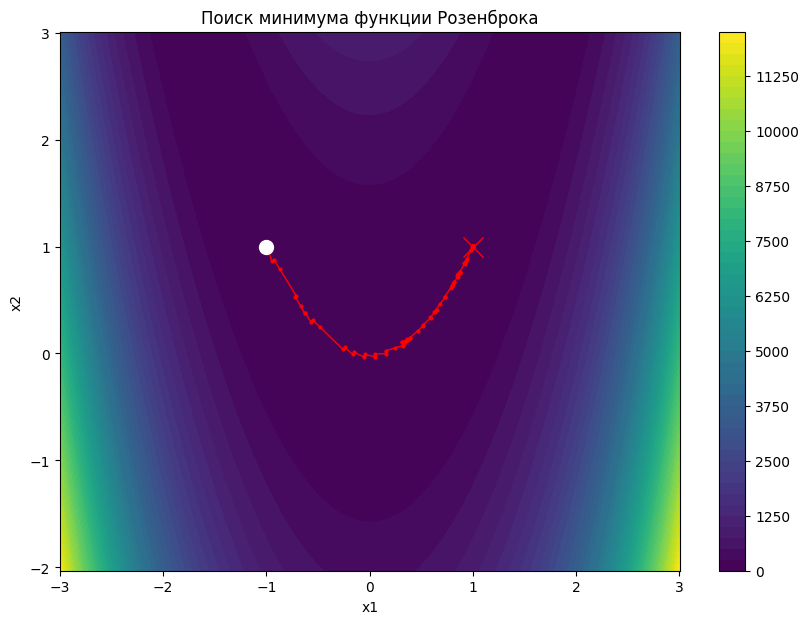

x1 = 1.00001
x2 = 1.00003
f(x) = 0.00000
Всего итераций (поворотов осей): 38
Всего вызовов функции: 501


In [21]:
start_point = [-1, 1]
min_point, iters, path, func_evals = rosenbrock_optimization(f_rozenbrok, start_point)

path = np.array(path)
x1_vals = np.linspace(min(path[:,0]) - 2, max(path[:,0]) + 2, 200)
x2_vals = np.linspace(min(path[:,1]) - 2, max(path[:,1]) + 2, 200)
X1, X2 = np.meshgrid(x1_vals, x2_vals)
Z = 100 * (X1**2 - X2)**2 + (X1 - 1)**2
plt.figure(figsize=(10, 7))
cp = plt.contourf(X1, X2, Z, levels=50, cmap='viridis')
plt.colorbar(cp)
plt.plot(path[:, 0], path[:, 1], 'r.-', markersize=4, linewidth=1)
plt.plot(start_point[0], start_point[1], 'white', marker='o', markersize=10)
plt.plot(min_point[0], min_point[1], 'red', marker='x', markersize=15)
plt.title('Поиск минимума функции Розенброка')
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

print(f"x1 = {min_point[0]:.5f}")
print(f"x2 = {min_point[1]:.5f}")
print(f"f(x) = {f_rozenbrok(min_point):.5f}")
print(f"Всего итераций (поворотов осей): {iters}")
print(f"Всего вызовов функции: {func_evals}")

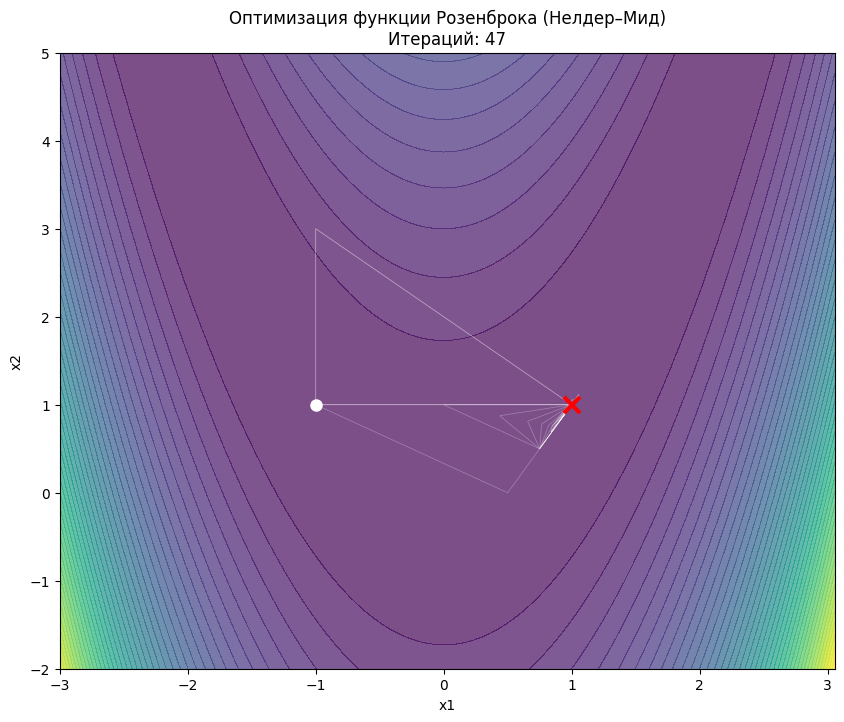

Точка минимума:
x1 = 1.00000
x2 = 1.00000
Значение функции: 0.00000
Всего итераций: 47
Всего вызовов функции: 234


In [22]:
start_p = [-1, 1]
min_p, simplex_history, total_iters, func_evals = nelder_mead_optimization(f_rozenbrok, start_p, step=2.0)

path_points = np.vstack(simplex_history)

x1_range = np.linspace(np.min(path_points[:,0]) - 2, np.max(path_points[:,0]) + 2, 100)
x2_range = np.linspace(np.min(path_points[:,1]) - 2, np.max(path_points[:,1]) + 2, 100)

X1, X2 = np.meshgrid(x1_range, x2_range)
Z = 100 * (X1**2 - X2)**2 + (X1 - 1)**2

plt.figure(figsize=(10, 8))
plt.contourf(X1, X2, Z, levels=50, cmap='viridis', alpha=0.7)

for i, tri in enumerate(simplex_history):
    polygon = plt.Polygon(tri, fill=False, edgecolor='white', alpha=0.3, linewidth=0.5)
    plt.gca().add_patch(polygon)
    plt.plot(tri[0,0], tri[0,1], 'r.', markersize=2)

plt.plot(start_p[0], start_p[1], 'wo', markersize=8)
plt.plot(min_p[0], min_p[1], 'rx', markersize=12, markeredgewidth=3)

plt.title(f'Оптимизация функции Розенброка (Нелдер–Мид)\nИтераций: {total_iters}')
plt.xlabel('x1')
plt.ylabel('x2')

plt.show()


print("Точка минимума:")
print(f"x1 = {min_p[0]:.5f}")
print(f"x2 = {min_p[1]:.5f}")
print(f"Значение функции: {f_rozenbrok(min_p):.5f}")
print(f"Всего итераций: {total_iters}")
print(f"Всего вызовов функции: {func_evals}")

| Параметр | x1 | x2 | f(x1, x2) | Число итераций | Число итераций |
| :--- | :---: | :---: | :---: | :---: | :---: |
| **Пакетный метод** | 1.0000 | 1.0000 | 0.0000 | - | - |
| **Метод Розенброка** | 1.0000 | 1.0000 | 0.0000 | 38 | 501 |
| **Метод Нелдера-Мида** | 1.0000 | 1.0000 | 0.0000 | 47 | 234 |

## Оптимизация функции Химмельблау

$$f(x_1, x_2) = 100(x_1^2 + x_2 - 11)^2 + (x_1 + x_2^2 - 7)^2$$

In [29]:
def f_himmelblau(x):
    x1, x2 = x[0], x[1]
    return 100 * (x1**2 + x2 - 11)**2 + (x1 + x2**2 - 7)**2

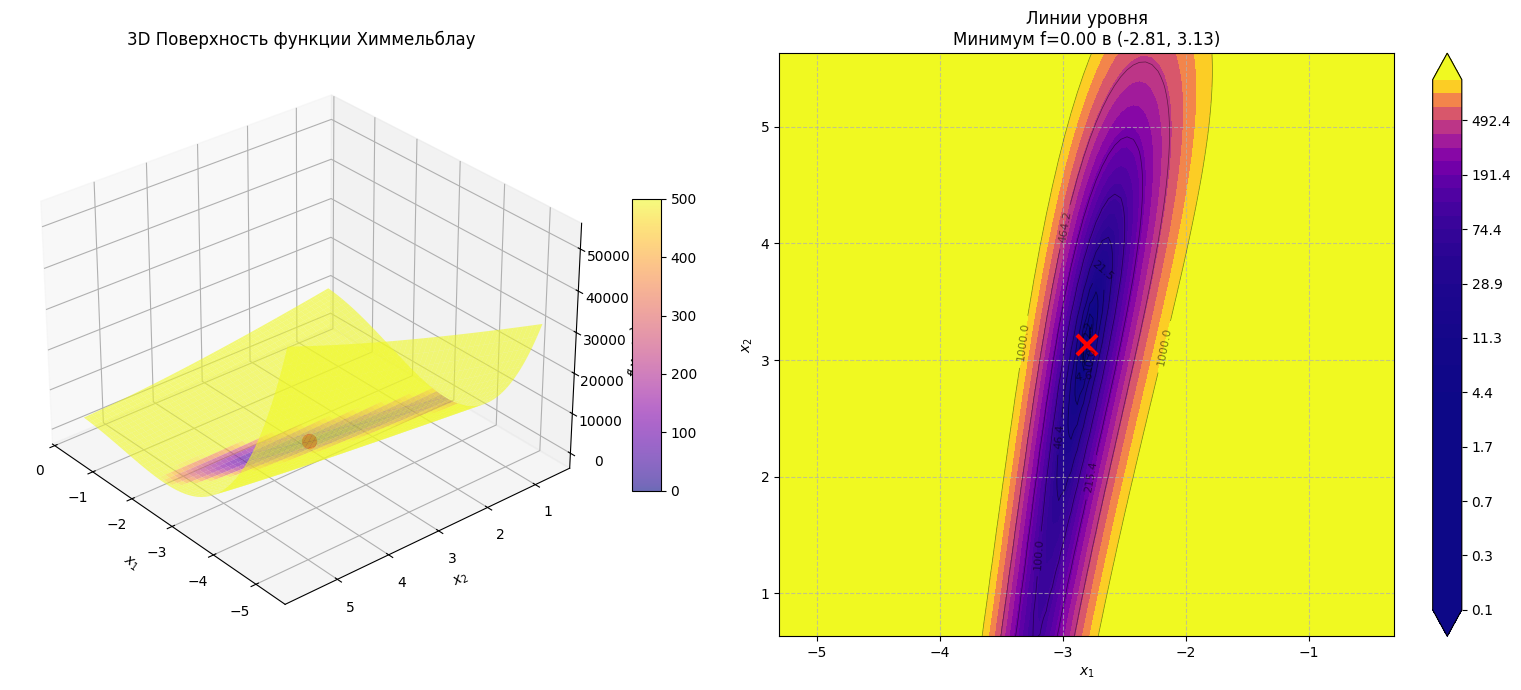

Точка минимума
x1 = -2.805
x2 = 3.131
Значение функции в этой точке: 0.000


In [40]:
x_min_arr = np.array([-2.805, 3.131])
f_min_val = f_himmelblau(x_min_arr)

buffer = 2.5
x1_range = np.linspace(x_min_arr[0] - buffer, x_min_arr[0] + buffer, 100)
x2_range = np.linspace(x_min_arr[1] - buffer, x_min_arr[1] + buffer, 100)
X1, X2 = np.meshgrid(x1_range, x2_range)
Z = f_himmelblau([X1, X2])
fig = plt.figure(figsize=(16, 7))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf = ax1.plot_surface(X1, X2, Z, cmap='plasma', edgecolor='none', alpha=0.6, 
                        norm=plt.Normalize(vmin=0, vmax=500))
ax1.scatter(x_min_arr[0], x_min_arr[1], f_min_val, color='red', s=100)
ax1.set_title('3D Поверхность функции Химмельблау')
ax1.set_xlabel('$x_1$')
ax1.set_ylabel('$x_2$')
ax1.set_zlabel('$f(x_1, x_2)$')
ax1.view_init(elev=30, azim=140)
fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=10)
ax2 = fig.add_subplot(1, 2, 2)
levels = np.logspace(-1, 3, 40) 
contour_filled = ax2.contourf(X1, X2, Z, levels=levels, cmap='plasma', extend='both')
fig.colorbar(contour_filled, ax=ax2) 
contours = ax2.contour(X1, X2, Z, levels=np.logspace(0, 3, 10), colors='black', alpha=0.5, linewidths=0.5)
ax2.clabel(contours, inline=True, fontsize=8)
ax2.plot(x_min_arr[0], x_min_arr[1], 'rx', markersize=15, markeredgewidth=3)
ax2.set_title(f'Линии уровня\nМинимум f={f_min_val:.2f} в ({x_min_arr[0]:.2f}, {x_min_arr[1]:.2f})')
ax2.set_xlabel('$x_1$')
ax2.set_ylabel('$x_2$')
ax2.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

x0 = [-1.2, 1.0]
res = minimize(f_himmelblau, x0, method='BFGS')
print(f"Точка минимума\nx1 = {res.x[0]:.3f}\nx2 = {res.x[1]:.3f}")
print(f"Значение функции в этой точке: {res.fun:.3f}")

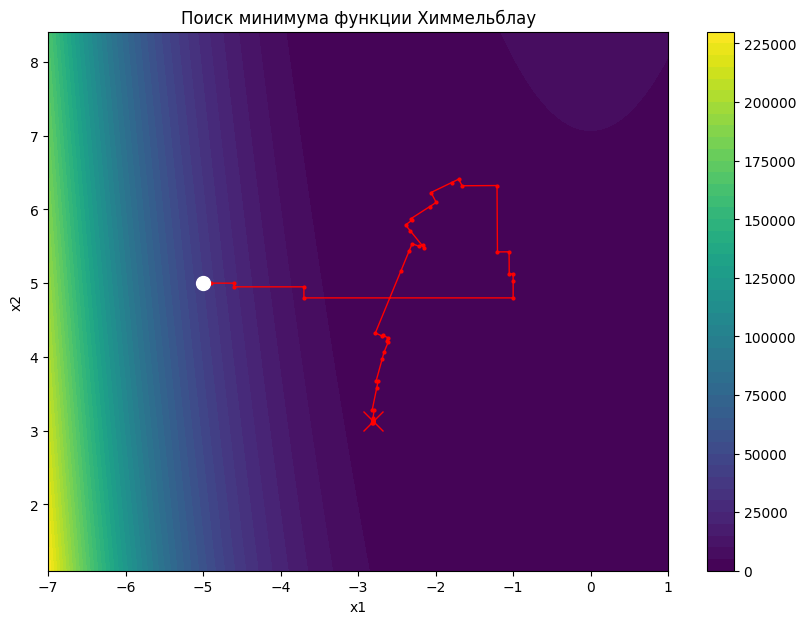

x1 = -2.805
x2 = 3.131
f(x) = 0.000
Всего итераций (поворотов осей): 21
Всего вызовов функции: 305


In [43]:
start_point = [-5, 5]
min_point, iters, path, func_evals = rosenbrock_optimization(f_himmelblau, start_point)

path = np.array(path)
x1_vals = np.linspace(min(path[:,0]) - 2, max(path[:,0]) + 2, 200)
x2_vals = np.linspace(min(path[:,1]) - 2, max(path[:,1]) + 2, 200)
X1, X2 = np.meshgrid(x1_vals, x2_vals)
Z = 100 * (X1**2 - X2)**2 + (X1 - 1)**2
plt.figure(figsize=(10, 7))
cp = plt.contourf(X1, X2, Z, levels=50, cmap='viridis')
plt.colorbar(cp)
plt.plot(path[:, 0], path[:, 1], 'r.-', markersize=4, linewidth=1)
plt.plot(start_point[0], start_point[1], 'white', marker='o', markersize=10)
plt.plot(min_point[0], min_point[1], 'red', marker='x', markersize=15)
plt.title('Поиск минимума функции Химмельблау')
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

print(f"x1 = {min_point[0]:.3f}")
print(f"x2 = {min_point[1]:.3f}")
print(f"f(x) = {f_himmelblau(min_point):.3f}")
print(f"Всего итераций (поворотов осей): {iters}")
print(f"Всего вызовов функции: {func_evals}")

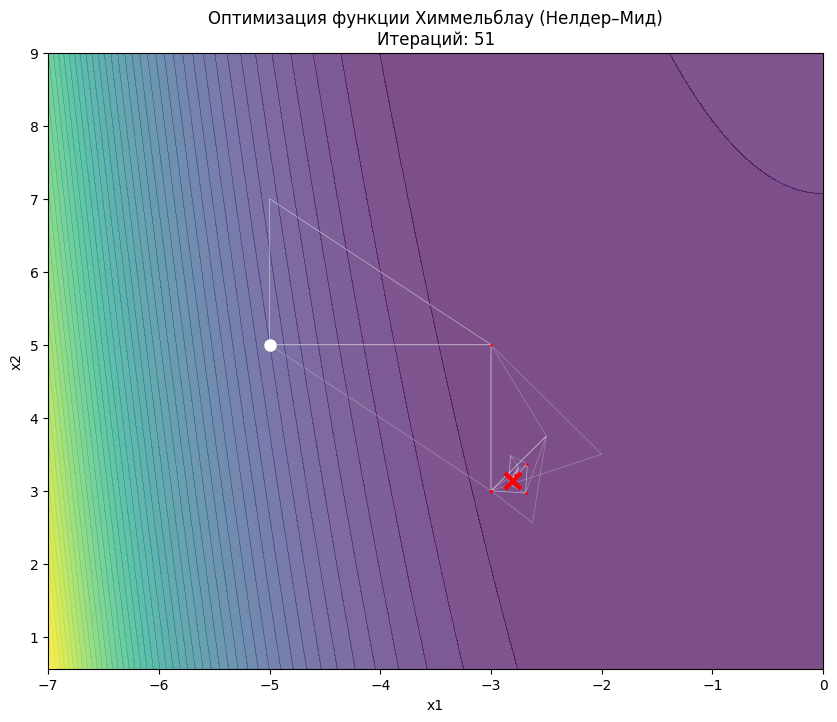

Точка минимума:
x1 = -2.805
x2 = 3.131
Значение функции: 0.000
Всего итераций: 51
Всего вызовов функции: 253


In [44]:
start_p = [-5, 5]
min_p, simplex_history, total_iters, func_evals = nelder_mead_optimization(f_himmelblau, start_p, step=2.0)

path_points = np.vstack(simplex_history)

x1_range = np.linspace(np.min(path_points[:,0]) - 2, np.max(path_points[:,0]) + 2, 100)
x2_range = np.linspace(np.min(path_points[:,1]) - 2, np.max(path_points[:,1]) + 2, 100)

X1, X2 = np.meshgrid(x1_range, x2_range)
Z = 100 * (X1**2 - X2)**2 + (X1 - 1)**2

plt.figure(figsize=(10, 8))
plt.contourf(X1, X2, Z, levels=50, cmap='viridis', alpha=0.7)

for i, tri in enumerate(simplex_history):
    polygon = plt.Polygon(tri, fill=False, edgecolor='white', alpha=0.3, linewidth=0.5)
    plt.gca().add_patch(polygon)
    plt.plot(tri[0,0], tri[0,1], 'r.', markersize=2)

plt.plot(start_p[0], start_p[1], 'wo', markersize=8)
plt.plot(min_p[0], min_p[1], 'rx', markersize=12, markeredgewidth=3)

plt.title(f'Оптимизация функции Химмельблау (Нелдер–Мид)\nИтераций: {total_iters}')
plt.xlabel('x1')
plt.ylabel('x2')

plt.show()


print("Точка минимума:")
print(f"x1 = {min_p[0]:.3f}")
print(f"x2 = {min_p[1]:.3f}")
print(f"Значение функции: {f_himmelblau(min_p):.3f}")
print(f"Всего итераций: {total_iters}")
print(f"Всего вызовов функции: {func_evals}")

| Параметр | x1 | x2 | f(x1, x2) | Число итераций | Число вычислений функции |
| :--- | :---: | :---: | :---: | :---: | :---: |
| **Пакетный метод** | -2.805 | 3.131 | 0.000 | - | - |
| **Метод Розенброка** | -2.805 | 3.131 | 0.000 | 21 | 305 |
| **Метод Нелдера-Мида** | 2.805 | 3.131 | 0.000 | 51 | 253 |

## **Вывод:**  
На всех функциях оба метода обеспечивают сходимость с точностью 0.0001, но метод Розенброка сходится значительно быстрее. Но в случае, когда на функции Розенброка требовалась точность 0.00001 - меетод Розенброка не сошелся с необходимой точностью. Число вызовов функции зависит от функции.